# **Pytorch**

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.nn import TransformerDecoder, TransformerDecoderLayer
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd



In [ ]:
# Load your data
text_features = np.load('text_features.npy')  # Shape: (2199, 768)
visual_features = np.load('visual_features.npy')  # Shape: (2199, 128)
audio_features = np.load('audio_features.npy')  # Shape: (2199, 74)
labels_df = pd.read_csv('labels.csv')  # Assuming it contains "annotation" and "mode" columns

# Map text labels to numerical values
label_map = {'Positive': 0, 'Neutral': 1, 'Negative': 2}
labels = labels_df['annotation'].map(label_map).values

# Create dataset splits based on "mode" column
train_mask = labels_df['mode'] == 'train'
val_mask = labels_df['mode'] == 'valid'
test_mask = labels_df['mode'] == 'test'

class MOSIDataset(Dataset):
    def __init__(self, text, visual, audio, labels):
        self.text = torch.FloatTensor(text)
        self.visual = torch.FloatTensor(visual)
        self.audio = torch.FloatTensor(audio)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'text': self.text[idx],
            'visual': self.visual[idx],
            'audio': self.audio[idx],
            'label': self.labels[idx]
        }

# Create datasets
train_dataset = MOSIDataset(
    text_features[train_mask],
    visual_features[train_mask],
    audio_features[train_mask],
    labels[train_mask]
)

val_dataset = MOSIDataset(
    text_features[val_mask],
    visual_features[val_mask],
    audio_features[val_mask],
    labels[val_mask]
)

test_dataset = MOSIDataset(
    text_features[test_mask],
    visual_features[test_mask],
    audio_features[test_mask],
    labels[test_mask]
)

# Model Implementation
class ModalityFusionCell(nn.Module):
    def __init__(self, input_dim_a, input_dim_b, hidden_dim=256, nhead=4, num_layers=2):
        super(ModalityFusionCell, self).__init__()

        # Contextual information extraction
        self.bigru_a = nn.GRU(input_dim_a, hidden_dim//2, bidirectional=True, batch_first=True)
        self.bigru_b = nn.GRU(input_dim_b, hidden_dim//2, bidirectional=True, batch_first=True)

        self.proj_a = nn.Linear(hidden_dim, hidden_dim)
        self.proj_b = nn.Linear(hidden_dim, hidden_dim)

        # Forward Translation (A -> B)
        encoder_layer = TransformerEncoderLayer(hidden_dim, nhead, hidden_dim)
        self.encoder_a2b = TransformerEncoder(encoder_layer, num_layers)

        decoder_layer = TransformerDecoderLayer(hidden_dim, nhead, hidden_dim)
        self.decoder_a2b = TransformerDecoder(decoder_layer, num_layers)

        # Backward Translation (B -> A)
        encoder_layer = TransformerEncoderLayer(hidden_dim, nhead, hidden_dim)
        self.encoder_b2a = TransformerEncoder(encoder_layer, num_layers)

        decoder_layer = TransformerDecoderLayer(hidden_dim, nhead, hidden_dim)
        self.decoder_b2a = TransformerDecoder(decoder_layer, num_layers)

        # Projection layers for translation evaluation
        self.proj_a2b = nn.Linear(hidden_dim, input_dim_b)
        self.proj_b2a = nn.Linear(hidden_dim, input_dim_a)

    def forward(self, x_a, x_b):
        # Contextual information extraction
        h_a, _ = self.bigru_a(x_a.unsqueeze(1))  # Add sequence dim
        h_a = h_a.squeeze(1)
        d_a = torch.tanh(self.proj_a(h_a))

        h_b, _ = self.bigru_b(x_b.unsqueeze(1))
        h_b = h_b.squeeze(1)
        d_b = torch.tanh(self.proj_b(h_b))

        # Forward Translation (A -> B)
        e_a2b = self.encoder_a2b(d_a.unsqueeze(0))  # Add sequence dim for Transformer
        d_a2b = self.decoder_a2b(d_b.unsqueeze(0), e_a2b)
        d_a2b = d_a2b.squeeze(0)

        # Backward Translation (B -> A)
        e_b2a = self.encoder_b2a(d_b.unsqueeze(0))
        d_b2a = self.decoder_b2a(d_a.unsqueeze(0), e_b2a)
        d_b2a = d_b2a.squeeze(0)

        # Translation evaluation projections
        x_hat_a2b = self.proj_a2b(d_a2b)
        x_hat_b2a = self.proj_b2a(d_b2a)

        return e_a2b.squeeze(0), e_b2a.squeeze(0), d_a2b, d_b2a, x_hat_a2b, x_hat_b2a, d_a, d_b

class TransModality(nn.Module):
    def __init__(self, text_dim=768, visual_dim=128, audio_dim=74, hidden_dim=256,
                 nhead=4, num_layers=2, num_classes=3):
        super(TransModality, self).__init__()

        # Modality Fusion Cells
        self.tv_cell = ModalityFusionCell(text_dim, visual_dim, hidden_dim, nhead, num_layers)
        self.ta_cell = ModalityFusionCell(text_dim, audio_dim, hidden_dim, nhead, num_layers)

        # Classification layer
        self.classifier = nn.Linear(hidden_dim * 7, num_classes)  # 4 encoded + 3 projected features

    def forward(self, text, visual, audio):
        # Text-Visual fusion
        e_t2v, e_v2t, d_t2v, d_v2t, x_hat_t2v, x_hat_v2t, d_t_tv, d_v = self.tv_cell(text, visual)

        # Text-Audio fusion
        e_t2a, e_a2t, d_t2a, d_a2t, x_hat_t2a, x_hat_a2t, d_t_ta, d_a = self.ta_cell(text, audio)

        # Combine all features for classification
        f = torch.cat([e_t2v, e_v2t, e_t2a, e_a2t, d_t_tv, d_v, d_a], dim=-1)

        # Classification
        logits = self.classifier(f)

        return {
            'logits': logits,
            'x_hat_t2v': x_hat_t2v,
            'x_hat_v2t': x_hat_v2t,
            'x_hat_t2a': x_hat_t2a,
            'x_hat_a2t': x_hat_a2t
        }

def compute_loss(outputs, labels, text, visual, audio, lambda_t=0.1):
    # Classification loss
    ce_loss = F.cross_entropy(outputs['logits'], labels)

    # Translation losses (MAE)
    loss_t2v = F.l1_loss(outputs['x_hat_t2v'], visual)
    loss_v2t = F.l1_loss(outputs['x_hat_v2t'], text)
    loss_t2a = F.l1_loss(outputs['x_hat_t2a'], audio)
    loss_a2t = F.l1_loss(outputs['x_hat_a2t'], text)

    # Joint loss
    total_loss = ce_loss + lambda_t * (loss_t2v + loss_v2t + loss_t2a + loss_a2t)

    return total_loss, {
        'total': total_loss.item(),
        'ce': ce_loss.item(),
        't2v': loss_t2v.item(),
        'v2t': loss_v2t.item(),
        't2a': loss_t2a.item(),
        'a2t': loss_a2t.item()
    }

# Training Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransModality().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

# Training loop
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in loader:
        optimizer.zero_grad()

        text = batch['text'].to(device)
        visual = batch['visual'].to(device)
        audio = batch['audio'].to(device)
        labels = batch['label'].to(device)

        outputs = model(text, visual, audio)
        loss, loss_dict = compute_loss(outputs, labels, text, visual, audio)

        loss.backward()
        optimizer.step()

        total_loss += loss_dict['total']
        preds = torch.argmax(outputs['logits'], dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), acc, f1

# Evaluation function
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            text = batch['text'].to(device)
            visual = batch['visual'].to(device)
            audio = batch['audio'].to(device)
            labels = batch['label'].to(device)

            outputs = model(text, visual, audio)
            loss, loss_dict = compute_loss(outputs, labels, text, visual, audio)

            total_loss += loss_dict['total']
            preds = torch.argmax(outputs['logits'], dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), acc, f1

# Main training loop
best_val_f1 = 0
for epoch in range(50):
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, optimizer)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
    print("----------------------------------------")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model.pth')
        print("Saved new best model")

# Test evaluation
model.load_state_dict(torch.load('best_model.pth'))
test_loss, test_acc, test_f1 = evaluate(model, test_loader)
print(f"\nFinal Test Results:")
print(f"Loss: {test_loss:.4f} | Accuracy: {test_acc:.4f} | F1: {test_f1:.4f}")

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1:
Train Loss: 1.8563 | Acc: 0.6129 | F1: 0.5963
Val Loss: 1.8143 | Acc: 0.6332 | F1: 0.5828
----------------------------------------
Saved new best model
Epoch 2:
Train Loss: 1.6411 | Acc: 0.7251 | F1: 0.7084
Val Loss: 1.7696 | Acc: 0.6550 | F1: 0.6167
----------------------------------------
Saved new best model
Epoch 3:
Train Loss: 1.5760 | Acc: 0.7516 | F1: 0.7352
Val Loss: 1.6479 | Acc: 0.7555 | F1: 0.7336
----------------------------------------
Saved new best model
Epoch 4:
Train Loss: 1.4672 | Acc: 0.8014 | F1: 0.7854
Val Loss: 1.6576 | Acc: 0.7380 | F1: 0.7174
----------------------------------------
Epoch 5:
Train Loss: 1.4151 | Acc: 0.8185 | F1: 0.8032
Val Loss: 1.6731 | Acc: 0.7380 | F1: 0.7173
----------------------------------------
Epoch 6:
Train Loss: 1.3377 | Acc: 0.8419 | F1: 0.8308
Val Loss: 1.6619 | Acc: 0.7467 | F1: 0.7254
----------------------------------------
Epoch 7:
Train Loss: 1.3006 | Acc: 0.8614 | F1: 0.8531
Val Loss: 1.6808 | Acc: 0.7511 | F1: 0.729

# **Pytorch with early stopping**

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
Epoch 1: 100%|██████████| 41/41 [00:08<00:00,  4.61batch/s, loss=1.61]


Epoch 1: Train Loss: 1.8594, Acc: 0.6098 | Val Loss: 1.8196, Acc: 0.6245


Epoch 2: 100%|██████████| 41/41 [00:07<00:00,  5.27batch/s, loss=1.28]


Epoch 2: Train Loss: 1.6376, Acc: 0.7407 | Val Loss: 1.6600, Acc: 0.7467


Epoch 3: 100%|██████████| 41/41 [00:08<00:00,  4.68batch/s, loss=2.07]


...

Epoch 7: Train Loss: 1.2658, Acc: 0.8738 | Val Loss: 1.7084, Acc: 0.6987


Epoch 8: 100%|██████████| 41/41 [00:08<00:00,  4.73batch/s, loss=1.01]


Epoch 8: Train Loss: 1.2304, Acc: 0.8777 | Val Loss: 1.7959, Acc: 0.7205


Epoch 9: 100%|██████████| 41/41 [00:11<00:00,  3.61batch/s, loss=1.52]


Epoch 9: Train Loss: 1.1841, Acc: 0.8980 | Val Loss: 1.7711, Acc: 0.7249
Early stopping triggered


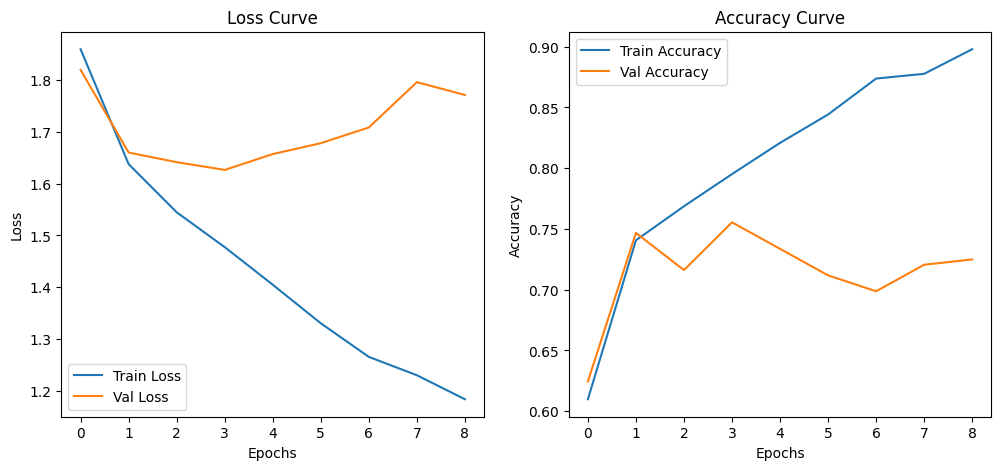

Test Accuracy: 0.7536


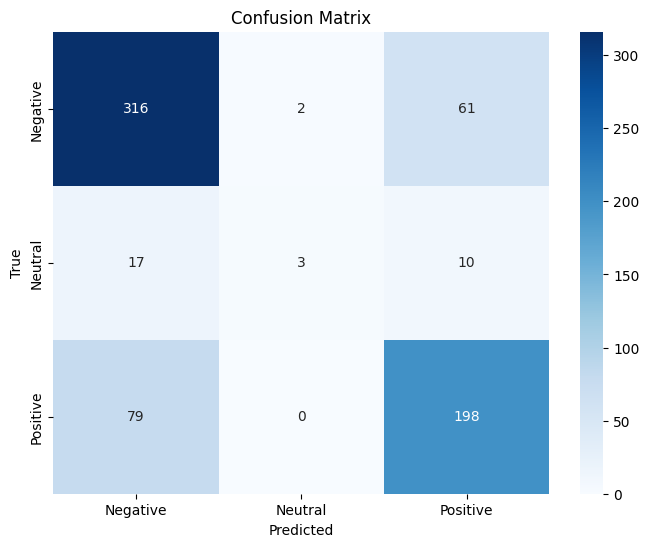

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.nn import TransformerDecoder, TransformerDecoderLayer
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load features and labels
text_features = np.load('text_features.npy')
visual_features = np.load('visual_features.npy')
audio_features = np.load('audio_features.npy')
labels_df = pd.read_csv('labels.csv')  # Assuming CSV format

# Encode labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels_df['annotation'])

# Split data based on 'mode' column
train_mask = labels_df['mode'] == 'train'
val_mask = labels_df['mode'] == 'valid'
test_mask = labels_df['mode'] == 'test'

X_train = {
    'text': text_features[train_mask],
    'visual': visual_features[train_mask],
    'audio': audio_features[train_mask],
    'labels': labels[train_mask]
}

X_val = {
    'text': text_features[val_mask],
    'visual': visual_features[val_mask],
    'audio': audio_features[val_mask],
    'labels': labels[val_mask]
}

X_test = {
    'text': text_features[test_mask],
    'visual': visual_features[test_mask],
    'audio': audio_features[test_mask],
    'labels': labels[test_mask]
}

class MultimodalDataset(Dataset):
    def __init__(self, data):
        self.text = torch.FloatTensor(data['text'])
        self.visual = torch.FloatTensor(data['visual'])
        self.audio = torch.FloatTensor(data['audio'])
        self.labels = torch.LongTensor(data['labels'])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'text': self.text[idx],
            'visual': self.visual[idx],
            'audio': self.audio[idx],
            'label': self.labels[idx]
        }

train_dataset = MultimodalDataset(X_train)
val_dataset = MultimodalDataset(X_val)
test_dataset = MultimodalDataset(X_test)

# Model definition (same as before)
class ModalityFusionCell(nn.Module):
    def __init__(self, input_dim_a, input_dim_b, hidden_dim, nhead, num_layers):
        super(ModalityFusionCell, self).__init__()

        self.bigru_a = nn.GRU(input_dim_a, hidden_dim//2, bidirectional=True, batch_first=True)
        self.bigru_b = nn.GRU(input_dim_b, hidden_dim//2, bidirectional=True, batch_first=True)

        self.proj_a = nn.Linear(hidden_dim, hidden_dim)
        self.proj_b = nn.Linear(hidden_dim, hidden_dim)

        encoder_layer = TransformerEncoderLayer(hidden_dim, nhead, hidden_dim)
        self.encoder_a2b = TransformerEncoder(encoder_layer, num_layers)

        decoder_layer = TransformerDecoderLayer(hidden_dim, nhead, hidden_dim)
        self.decoder_a2b = TransformerDecoder(decoder_layer, num_layers)

        encoder_layer = TransformerEncoderLayer(hidden_dim, nhead, hidden_dim)
        self.encoder_b2a = TransformerEncoder(encoder_layer, num_layers)

        decoder_layer = TransformerDecoderLayer(hidden_dim, nhead, hidden_dim)
        self.decoder_b2a = TransformerDecoder(decoder_layer, num_layers)

        self.proj_a2b = nn.Linear(hidden_dim, input_dim_b)
        self.proj_b2a = nn.Linear(hidden_dim, input_dim_a)

    def forward(self, x_a, x_b):
        h_a, _ = self.bigru_a(x_a.unsqueeze(1))
        h_a = h_a.squeeze(1)
        d_a = torch.tanh(self.proj_a(h_a))

        h_b, _ = self.bigru_b(x_b.unsqueeze(1))
        h_b = h_b.squeeze(1)
        d_b = torch.tanh(self.proj_b(h_b))

        e_a2b = self.encoder_a2b(d_a.unsqueeze(0))
        d_a2b = self.decoder_a2b(d_b.unsqueeze(0), e_a2b)
        d_a2b = d_a2b.squeeze(0)

        e_b2a = self.encoder_b2a(d_b.unsqueeze(0))
        d_b2a = self.decoder_b2a(d_a.unsqueeze(0), e_b2a)
        d_b2a = d_b2a.squeeze(0)

        x_hat_a2b = self.proj_a2b(d_a2b)
        x_hat_b2a = self.proj_b2a(d_b2a)

        return e_a2b.squeeze(0), e_b2a.squeeze(0), d_a2b, d_b2a, x_hat_a2b, x_hat_b2a, d_a, d_b

class TransModality(nn.Module):
    def __init__(self, text_dim, visual_dim, acoustic_dim, hidden_dim=256, nhead=4, num_layers=2, num_classes=3):
        super(TransModality, self).__init__()

        self.tv_cell = ModalityFusionCell(text_dim, visual_dim, hidden_dim, nhead, num_layers)
        self.ta_cell = ModalityFusionCell(text_dim, acoustic_dim, hidden_dim, nhead, num_layers)

        self.classifier = nn.Linear(hidden_dim * 7, num_classes)

    def forward(self, text, visual, acoustic):
        e_t2v, e_v2t, d_t2v, d_v2t, x_hat_t2v, x_hat_v2t, d_t_tv, d_v = self.tv_cell(text, visual)
        e_t2a, e_a2t, d_t2a, d_a2t, x_hat_t2a, x_hat_a2t, d_t_ta, d_a = self.ta_cell(text, acoustic)

        f = torch.cat([e_t2v, e_v2t, e_t2a, e_a2t, d_t_tv, d_v, d_a], dim=-1)
        logits = self.classifier(f)

        return {
            'logits': logits,
            'x_hat_t2v': x_hat_t2v,
            'x_hat_v2t': x_hat_v2t,
            'x_hat_t2a': x_hat_t2a,
            'x_hat_a2t': x_hat_a2t
        }

def compute_loss(outputs, labels, text, visual, acoustic, lambda_t=0.1):
    ce_loss = F.cross_entropy(outputs['logits'], labels)

    loss_t2v = F.l1_loss(outputs['x_hat_t2v'], visual)
    loss_v2t = F.l1_loss(outputs['x_hat_v2t'], text)
    loss_t2a = F.l1_loss(outputs['x_hat_t2a'], acoustic)
    loss_a2t = F.l1_loss(outputs['x_hat_a2t'], text)

    total_loss = ce_loss + lambda_t * (loss_t2v + loss_v2t + loss_t2a + loss_a2t)

    return total_loss, {
        'total': total_loss.item(),
        'ce': ce_loss.item(),
        't2v': loss_t2v.item(),
        'v2t': loss_v2t.item(),
        't2a': loss_t2a.item(),
        'a2t': loss_a2t.item()
    }

# Training setup
text_dim = 768
visual_dim = 128
audio_dim = 74
num_classes = 3  # Positive, Negative, Neutral

model = TransModality(text_dim, visual_dim, audio_dim, num_classes=num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Early stopping callback
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_score is None:
            self.best_score = val_loss
        elif val_loss > self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_loss
            self.counter = 0

# Training loop with tqdm and early stopping
def train_model(model, train_loader, val_loader, optimizer, epochs=50):
    early_stopping = EarlyStopping(patience=5, delta=0.001)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []

        # Training phase with tqdm
        with tqdm(train_loader, unit="batch") as tepoch:
            for batch in tepoch:
                tepoch.set_description(f"Epoch {epoch+1}")

                text = batch['text'].to(device)
                visual = batch['visual'].to(device)
                audio = batch['audio'].to(device)
                labels = batch['label'].to(device)

                optimizer.zero_grad()
                outputs = model(text, visual, audio)
                loss, loss_dict = compute_loss(outputs, labels, text, visual, audio)

                loss.backward()
                optimizer.step()

                train_loss += loss_dict['total']
                preds = torch.argmax(outputs['logits'], dim=1)
                train_preds.extend(preds.cpu().numpy())
                train_labels.extend(labels.cpu().numpy())

                tepoch.set_postfix(loss=loss_dict['total'])

        # Validation phase
        val_loss, val_acc = evaluate(model, val_loader)
        train_loss /= len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)

        # Update history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

        # Early stopping check
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break

    return history

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            text = batch['text'].to(device)
            visual = batch['visual'].to(device)
            audio = batch['audio'].to(device)
            labels = batch['label'].to(device)

            outputs = model(text, visual, audio)
            loss, loss_dict = compute_loss(outputs, labels, text, visual, audio)

            total_loss += loss_dict['total']
            preds = torch.argmax(outputs['logits'], dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), acc

def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Train the model
history = train_model(model, train_loader, val_loader, optimizer, epochs=50)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Test evaluation
test_loss, test_acc = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion matrix
test_preds = []
test_labels = []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        text = batch['text'].to(device)
        visual = batch['visual'].to(device)
        audio = batch['audio'].to(device)
        labels = batch['label'].to(device)

        outputs = model(text, visual, audio)
        preds = torch.argmax(outputs['logits'], dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

plot_confusion_matrix(test_labels, test_preds, label_encoder.classes_)

# **Tensorflow**

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 57s 182ms/step - accuracy: 0.4973 - loss: 1.2903 - val_accuracy: 0.5983 - val_loss: 0.8488
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.6938 - loss: 0.6843 - val_accuracy: 0.5546 - val_loss: 1.0940
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.7495 - loss: 0.5814 - val_accuracy: 0.6463 - val_loss: 0.8678
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.7769 - loss: 0.5941 - val_accuracy: 0.7118 - val_loss: 0.7575
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.8015 - loss: 0.4937 - val_accuracy: 0.7555 - val_loss: 0.7754
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.8145 - loss: 0.4741 - val_accuracy: 0.7511 - val_loss: 0.8338
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.8597 - loss: 0.3564 - val_accuracy: 0.7293 - val_loss: 0.9143
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.8414 - loss: 0.4291 - val_accuracy: 0.729

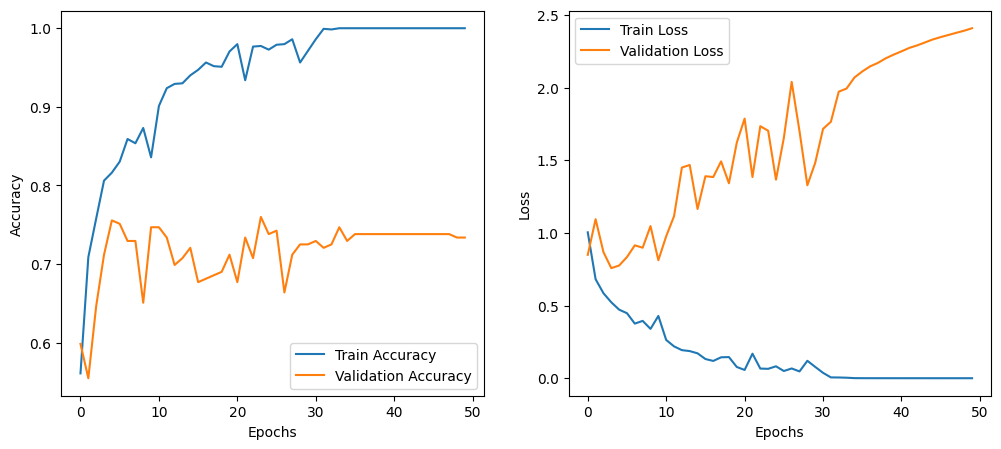

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step


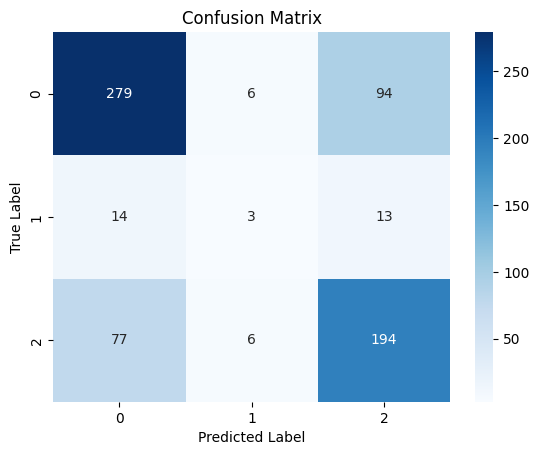

              precision    recall  f1-score   support

           0       0.75      0.74      0.74       379
           1       0.20      0.10      0.13        30
           2       0.64      0.70      0.67       277

    accuracy                           0.69       686
   macro avg       0.53      0.51      0.52       686
weighted avg       0.69      0.69      0.69       686

Test Accuracy: 0.6939
F1 Score: 0.6885


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, GRU, Input, LayerNormalization, Bidirectional, Reshape
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

# Load Features and Labels
text_features = np.load("text_features.npy")
visual_features = np.load("visual_features.npy")
audio_features = np.load("audio_features.npy")
labels_df = pd.read_csv("labels.csv")

# Convert labels to numerical values
label_mapping = {"Positive": 2, "Neutral": 1, "Negative": 0}
y_labels = labels_df["annotation"].map(label_mapping).values

# Split data into train, test, and validation
train_idx = labels_df[labels_df["mode"] == "train"].index
test_idx = labels_df[labels_df["mode"] == "test"].index
valid_idx = labels_df[labels_df["mode"] == "valid"].index

X_train = [text_features[train_idx], visual_features[train_idx], audio_features[train_idx]]
y_train = y_labels[train_idx]
X_test = [text_features[test_idx], visual_features[test_idx], audio_features[test_idx]]
y_test = y_labels[test_idx]
X_valid = [text_features[valid_idx], visual_features[valid_idx], audio_features[valid_idx]]
y_valid = y_labels[valid_idx]

# Transformer Encoder Block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    x = tf.keras.layers.Dropout(dropout)(x)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + inputs)

    ffn = tf.keras.Sequential([
        Dense(ff_dim, activation="relu"),
        Dense(inputs.shape[-1]),
    ])
    x_ffn = ffn(x)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + x_ffn)
    return x

# Transformer Decoder Block
def transformer_decoder(inputs, enc_outputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, enc_outputs)
    x = tf.keras.layers.Dropout(dropout)(x)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + inputs)

    ffn = tf.keras.Sequential([
        Dense(ff_dim, activation="relu"),
        Dense(inputs.shape[-1]),
    ])
    x_ffn = ffn(x)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + x_ffn)
    return x

# Modality Fusion Cell
def modality_fusion_cell(input_a, input_b, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
    gru_a = Bidirectional(GRU(head_size, return_sequences=True))(input_a)
    gru_b = Bidirectional(GRU(head_size, return_sequences=True))(input_b)

    enc_a = transformer_encoder(gru_a, head_size, num_heads, ff_dim, dropout)
    dec_b = transformer_decoder(gru_b, enc_a, head_size, num_heads, ff_dim, dropout)

    enc_b = transformer_encoder(gru_b, head_size, num_heads, ff_dim, dropout)
    dec_a = transformer_decoder(gru_a, enc_b, head_size, num_heads, ff_dim, dropout)

    return enc_a, enc_b, dec_a, dec_b

# TransModality Model
def build_transmodality_model(text_shape, visual_shape, audio_shape, num_classes=3):
    text_input = Input(shape=(text_shape[0],), name="text_input")
    visual_input = Input(shape=(visual_shape[0],), name="visual_input")
    audio_input = Input(shape=(audio_shape[0],), name="audio_input")

    # Reshape inputs to add time dimension
    text_reshaped = Reshape((1, text_shape[0]))(text_input)
    visual_reshaped = Reshape((1, visual_shape[0]))(visual_input)
    audio_reshaped = Reshape((1, audio_shape[0]))(audio_input)

    enc_text_v, enc_v_text, dec_text_v, dec_v_text = modality_fusion_cell(text_reshaped, visual_reshaped)
    enc_text_a, enc_a_text, dec_text_a, dec_a_text = modality_fusion_cell(text_reshaped, audio_reshaped)

    fusion_output = tf.keras.layers.Concatenate()([
        enc_text_v, enc_v_text, enc_text_a, enc_a_text, dec_text_v, dec_v_text, dec_text_a, dec_a_text
    ])

    fusion_output = tf.keras.layers.Flatten()(fusion_output)
    fusion_output = Dense(128, activation="relu")(fusion_output)
    fusion_output = Dense(64, activation="relu")(fusion_output)

    output = Dense(num_classes, activation="softmax", name="output_layer")(fusion_output)

    model = Model(inputs=[text_input, visual_input, audio_input], outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    return model

# Model Training
model = build_transmodality_model((768,), (128,), (74,))
epochs = 50
batch_size = 32

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# Plot Accuracy and Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Confusion Matrix
y_pred = model.predict(X_test).argmax(axis=1)
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

# Print Test Accuracy and F-score
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")


Epoch 1/50
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5383 - loss: 1.1140

41/41 ━━━━━━━━━━━━━━━━━━━━ 78s 205ms/step - accuracy: 0.5405 - loss: 1.1038 - val_accuracy: 0.6419 - val_loss: 0.8170
Epoch 2/50
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7197 - loss: 0.6429

41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.7209 - loss: 0.6426 - val_accuracy: 0.6856 - val_loss: 0.7277
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.7913 - loss: 0.5872

41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.7910 - loss: 0.5873 - val_accuracy: 0.7773 - val_loss: 0.6703
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.7842 - loss: 0.5362 - val_accuracy: 0.7860 - val_loss: 0.7059
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.8304 - loss: 0.4476 - val_accuracy: 0.7424 - val_loss: 0.7280
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.8417 - loss: 0.4207 - val_accuracy: 0.6594 - val_loss: 0.8544
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.8380 - loss: 0.4233 - val_accuracy: 0.6987 - val_loss: 0.8556
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.8521 - loss: 0.3701 - val_accuracy: 0.7074 - val_loss: 0.8089
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.8708 - loss: 0.3381 - val_accuracy: 0.7031 - val_loss: 0.9672
Epoch 10/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.8889 - loss: 0.2754 - val_accuracy: 0.6550 - val_los

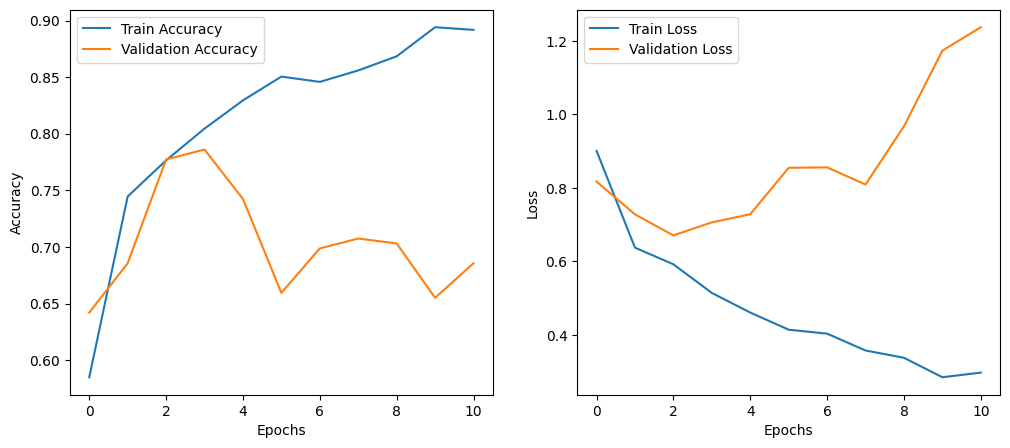

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step


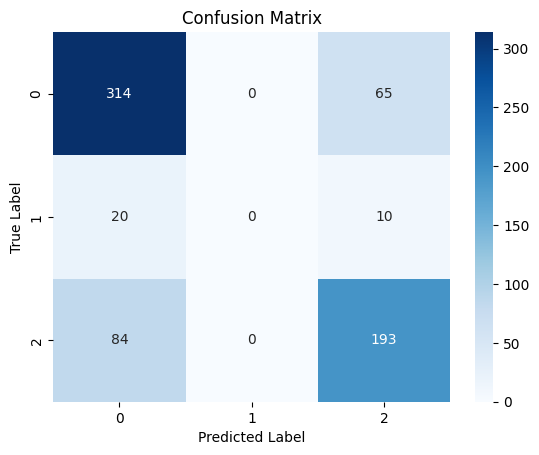

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.75      0.83      0.79       379
           1       0.00      0.00      0.00        30
           2       0.72      0.70      0.71       277

    accuracy                           0.74       686
   macro avg       0.49      0.51      0.50       686
weighted avg       0.71      0.74      0.72       686

Test Accuracy: 0.7391
F1 Score: 0.7213


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, GRU, Input, LayerNormalization, Bidirectional, Reshape
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

# Load Features and Labels
text_features = np.load("text_features.npy")
visual_features = np.load("visual_features.npy")
audio_features = np.load("audio_features.npy")
labels_df = pd.read_csv("labels.csv")

# Convert labels to numerical values
label_mapping = {"Positive": 2, "Neutral": 1, "Negative": 0}
y_labels = labels_df["annotation"].map(label_mapping).values

# Split data into train, test, and validation
train_idx = labels_df[labels_df["mode"] == "train"].index
test_idx = labels_df[labels_df["mode"] == "test"].index
valid_idx = labels_df[labels_df["mode"] == "valid"].index

X_train = [text_features[train_idx], visual_features[train_idx], audio_features[train_idx]]
y_train = y_labels[train_idx]
X_test = [text_features[test_idx], visual_features[test_idx], audio_features[test_idx]]
y_test = y_labels[test_idx]
X_valid = [text_features[valid_idx], visual_features[valid_idx], audio_features[valid_idx]]
y_valid = y_labels[valid_idx]

# Transformer Encoder Block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    x = tf.keras.layers.Dropout(dropout)(x)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + inputs)

    ffn = tf.keras.Sequential([
        Dense(ff_dim, activation="relu"),
        Dense(inputs.shape[-1]),
    ])
    x_ffn = ffn(x)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + x_ffn)
    return x

# Transformer Decoder Block
def transformer_decoder(inputs, enc_outputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, enc_outputs)
    x = tf.keras.layers.Dropout(dropout)(x)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + inputs)

    ffn = tf.keras.Sequential([
        Dense(ff_dim, activation="relu"),
        Dense(inputs.shape[-1]),
    ])
    x_ffn = ffn(x)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + x_ffn)
    return x

# Modality Fusion Cell
def modality_fusion_cell(input_a, input_b, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
    gru_a = Bidirectional(GRU(head_size, return_sequences=True))(input_a)
    gru_b = Bidirectional(GRU(head_size, return_sequences=True))(input_b)

    enc_a = transformer_encoder(gru_a, head_size, num_heads, ff_dim, dropout)
    dec_b = transformer_decoder(gru_b, enc_a, head_size, num_heads, ff_dim, dropout)

    enc_b = transformer_encoder(gru_b, head_size, num_heads, ff_dim, dropout)
    dec_a = transformer_decoder(gru_a, enc_b, head_size, num_heads, ff_dim, dropout)

    return enc_a, enc_b, dec_a, dec_b

# TransModality Model
def build_transmodality_model(text_shape, visual_shape, audio_shape, num_classes=3):
    text_input = Input(shape=(text_shape[0],), name="text_input")
    visual_input = Input(shape=(visual_shape[0],), name="visual_input")
    audio_input = Input(shape=(audio_shape[0],), name="audio_input")

    # Reshape inputs to add time dimension
    text_reshaped = Reshape((1, text_shape[0]))(text_input)
    visual_reshaped = Reshape((1, visual_shape[0]))(visual_input)
    audio_reshaped = Reshape((1, audio_shape[0]))(audio_input)

    enc_text_v, enc_v_text, dec_text_v, dec_v_text = modality_fusion_cell(text_reshaped, visual_reshaped)
    enc_text_a, enc_a_text, dec_text_a, dec_a_text = modality_fusion_cell(text_reshaped, audio_reshaped)

    fusion_output = tf.keras.layers.Concatenate()([
        enc_text_v, enc_v_text, enc_text_a, enc_a_text, dec_text_v, dec_v_text, dec_text_a, dec_a_text
    ])

    fusion_output = tf.keras.layers.Flatten()(fusion_output)
    fusion_output = Dense(128, activation="relu")(fusion_output)
    fusion_output = Dense(64, activation="relu")(fusion_output)

    output = Dense(num_classes, activation="softmax", name="output_layer")(fusion_output)

    model = Model(inputs=[text_input, visual_input, audio_input], outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    return model

# Model Training
model = build_transmodality_model((768,), (128,), (74,))
epochs = 50
batch_size = 32

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
checkpoint = tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min')

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    callbacks=[early_stopping, checkpoint]
)

# Plot Accuracy and Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Confusion Matrix
y_pred = model.predict(X_test).argmax(axis=1)
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

# Print Test Accuracy and F-score
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")


In [ ]:
! pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.3 MB/s eta 0:00:00


# **With sampling and hyperparameter**

Trial 10 Complete [00h 00m 53s]
val_accuracy: 0.36681222915649414

Best val_accuracy So Far: 0.7336244583129883
Total elapsed time: 00h 08m 50s
Best Hyperparameters: Head Size=32, Num Heads=4, FF Dim=256, Learning Rate=0.001
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.3775 - loss: 1.6640 - val_accuracy: 0.2620 - val_loss: 1.7279
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6784 - loss: 0.6791 - val_accuracy: 0.4672 - val_loss: 1.5448
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7931 - loss: 0.4856 - val_accuracy: 0.6856 - val_loss: 0.8529
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8725 - loss: 0.2491 - val_accuracy: 0.7031 - val_loss: 0.8847
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9136 - loss: 0.1742 - val_accuracy: 0.7205 - val_loss: 0.9395
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9257 - loss: 0.1403 - val_accuracy: 0.7293 - val_loss: 0.9573
Test Accurac

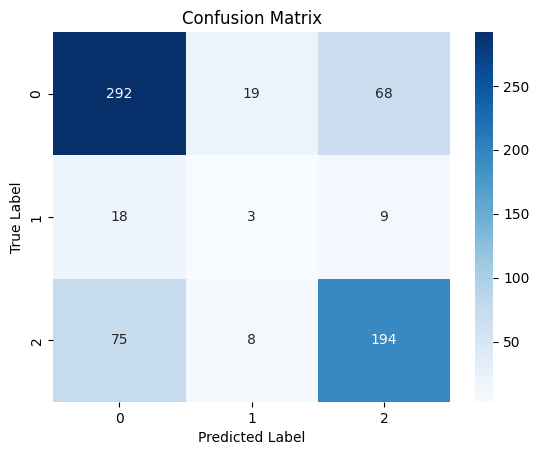

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, GRU, Input, LayerNormalization, Bidirectional, Reshape, Dropout, Flatten
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
from keras_tuner import HyperModel, RandomSearch
from tqdm import tqdm
from imblearn.over_sampling import SMOTE

# Load Features and Labels
text_features = np.load("text_features.npy")
visual_features = np.load("visual_features.npy")
audio_features = np.load("audio_features.npy")
labels_df = pd.read_csv("labels.csv")

# Convert labels to numerical values
label_mapping = {"Positive": 2, "Neutral": 1, "Negative": 0}
y_labels = labels_df["annotation"].map(label_mapping).values

# Split data into train, test, and validation
train_idx = labels_df[labels_df["mode"] == "train"].index
test_idx = labels_df[labels_df["mode"] == "test"].index
valid_idx = labels_df[labels_df["mode"] == "valid"].index

X_train = [text_features[train_idx], visual_features[train_idx], audio_features[train_idx]]
y_train = y_labels[train_idx]
X_test = [text_features[test_idx], visual_features[test_idx], audio_features[test_idx]]
y_test = y_labels[test_idx]
X_valid = [text_features[valid_idx], visual_features[valid_idx], audio_features[valid_idx]]
y_valid = y_labels[valid_idx]

# Compute class weights to handle imbalance
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# Apply SMOTE to oversample the minority class
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_flat = np.concatenate(X_train, axis=1)  # Flatten for SMOTE
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_flat, y_train)
X_train_resampled = [X_train_resampled[:, :768], X_train_resampled[:, 768:896], X_train_resampled[:, 896:]]

# HyperModel for tuning class
class TransModalityHyperModel(HyperModel):
    def build(self, hp):
        text_input = Input(shape=(768,), name="text_input")
        visual_input = Input(shape=(128,), name="visual_input")
        audio_input = Input(shape=(74,), name="audio_input")

        text_reshaped = Reshape((1, 768))(text_input)
        visual_reshaped = Reshape((1, 128))(visual_input)
        audio_reshaped = Reshape((1, 74))(audio_input)

        head_size = hp.Choice("head_size", [32, 64, 128])
        num_heads = hp.Choice("num_heads", [2, 4, 8])
        ff_dim = hp.Choice("ff_dim", [64, 128, 256])
        dropout_rate = hp.Float("dropout", 0.1, 0.5, step=0.1)

        def modality_fusion_cell(input_a, input_b):
            gru_a = Bidirectional(GRU(head_size, return_sequences=True))(input_a)
            gru_b = Bidirectional(GRU(head_size, return_sequences=True))(input_b)

            enc_a = LayerNormalization(epsilon=1e-6)(gru_a + gru_b)
            enc_b = LayerNormalization(epsilon=1e-6)(gru_b + gru_a)
            return enc_a, enc_b

        enc_text_v, enc_v_text = modality_fusion_cell(text_reshaped, visual_reshaped)
        enc_text_a, enc_a_text = modality_fusion_cell(text_reshaped, audio_reshaped)

        fusion_output = tf.keras.layers.Concatenate()([enc_text_v, enc_v_text, enc_text_a, enc_a_text])
        fusion_output = Flatten()(fusion_output)
        fusion_output = Dense(128, activation="relu")(fusion_output)
        fusion_output = Dropout(dropout_rate)(fusion_output)
        fusion_output = Dense(64, activation="relu")(fusion_output)

        output = Dense(3, activation="softmax", name="output_layer")(fusion_output)

        model = Model(inputs=[text_input, visual_input, audio_input], outputs=output)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])

        return model

# Hyperparameter tuning
tuner = RandomSearch(TransModalityHyperModel(), objective="val_accuracy", max_trials=10, executions_per_trial=1, directory="hyper_tuning", project_name="transmodality_tuning")

tuner.search(X_train_resampled, y_train_resampled, validation_data=(X_valid, y_valid), epochs=10, batch_size=32, class_weight=class_weight_dict, callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)])

# Get best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Hyperparameters: Head Size={best_hps.get('head_size')}, Num Heads={best_hps.get('num_heads')}, FF Dim={best_hps.get('ff_dim')}, Learning Rate={best_hps.get('learning_rate')}")

# Train with best hyperparameters
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(X_train_resampled, y_train_resampled, validation_data=(X_valid, y_valid), epochs=20, batch_size=32, class_weight=class_weight_dict, callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)])

# Evaluate Model
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred = best_model.predict(X_test).argmax(axis=1)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
